# 🧠 Entrenamiento Masivo LSTM para PM2.5 (Colab)
Este notebook está preparado para recibir el *Dataset Maestro de Colab* completo con todas las estaciones. El pipeline incluye:
1. **Exploración y visualización** de los datos
2. **Feature Engineering** con transformaciones cíclicas (seno/coseno)
3. **Normalización** con MinMaxScaler
4. Construcción de **ventanas temporales** por estación (sin cruzar secuencias)
5. Entrenamiento de un modelo **LSTM multicapa** aprovechando la GPU
6. **Evaluación** con métricas y gráficos (valores reales desnormalizados)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_PATH="/content/drive/MyDrive/Curso Especializacion/Proyecto/master_dataset_colab.csv"

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Asegúrate de subir tu master_dataset_colab.csv a esta misma ruta o modifica la ruta
#DATA_PATH = 'master_dataset_colab.csv'
MODEL_PATH = 'lstm_pm25_colab.keras'

# Estilo de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Librerías importadas correctamente')


✅ Librerías importadas correctamente


## 1. Carga de Datos

In [4]:
df = pd.read_csv(DATA_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)
print(f'Dimensiones del dataset: {df.shape}')
print(f'Estaciones disponibles: {df["station_name"].unique()}')
display(df.head())

Dimensiones del dataset: (195183, 21)
Estaciones disponibles: ['Francia' 'Molí del Sol' 'Pista de Silla' 'Puerto Moll Trans. Ponent'
 'Puerto Valencia' 'Puerto llit antic Túria' 'Universidad Politécnica']


,pm25,no2,o3,temperatura,velocidad_viento,precipitacion,humedad_relativa,hora_del_dia,dia_de_la_semana,pm25_lag1,...,pm25_lag3,pm25_rolling_6h,station_name,station_Francia,station_Molí del Sol,station_Pista de Silla,station_Puerto Moll Trans. Ponent,station_Puerto Valencia,station_Puerto llit antic Túria,station_Universidad Politécnica
fecha,,,,,,,,,,,,,,,,,,,,,
2017-01-09,8.0,20.0,56.0,10.4,0.8,0.0,60.0,0,0,10.0,...,9.0,8.500000,Francia,True,False,False,False,False,False,False
2017-01-09,8.0,16.0,60.0,10.4,0.8,0.0,60.0,0,0,8.0,...,8.0,8.500000,Francia,True,False,False,False,False,False,False
2017-01-09,8.0,15.0,58.0,10.4,0.8,0.0,60.0,0,0,8.0,...,10.0,8.500000,Francia,True,False,False,False,False,False,False
2017-01-09,9.0,13.0,58.0,10.4,0.8,0.0,60.0,0,0,8.0,...,8.0,8.500000,Francia,True,False,False,False,False,False,False
2017-01-09,9.0,14.0,56.0,10.4,0.8,0.0,60.0,0,0,9.0,...,8.0,8.666667,Francia,True,False,False,False,False,False,False


## 2. Exploración y Visualización de Datos (EDA)

Antes de entrenar el modelo, es fundamental **entender** los datos con los que trabajamos.
Analizaremos la distribución de las variables, las correlaciones y la evolución temporal del target (PM2.5).

In [5]:
# 2.1 Estadísticas descriptivas generales
print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
df.info()
print()

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
# Seleccionar solo columnas numéricas para describe
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[numeric_cols].describe())
print()

print("=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "✅ No hay valores nulos")


INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 195183 entries, 2017-01-09 to 2021-12-31
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   pm25                               195183 non-null  float64
 1   no2                                195183 non-null  float64
 2   o3                                 195183 non-null  float64
 3   temperatura                        195183 non-null  float64
 4   velocidad_viento                   195183 non-null  float64
 5   precipitacion                      195183 non-null  float64
 6   humedad_relativa                   195183 non-null  float64
 7   hora_del_dia                       195183 non-null  int64  
 8   dia_de_la_semana                   195183 non-null  int64  
 9   pm25_lag1                          195183 non-null  float64
 10  pm25_lag2                          195183 non-null  float64
 11 

,pm25,no2,o3,temperatura,velocidad_viento,precipitacion,humedad_relativa,hora_del_dia,dia_de_la_semana,pm25_lag1,pm25_lag2,pm25_lag3,pm25_rolling_6h
count,195183.000000,195183.000000,195183.000000,195183.000000,195183.000000,195183.000000,195183.000000,195183.0,195183.000000,195183.000000,195183.000000,195183.000000,195183.000000
mean,11.538018,22.486332,51.170483,18.875416,1.733809,1.283565,57.217898,0.0,3.002603,11.537588,11.537245,11.536666,11.536981
std,9.614789,19.877909,27.481065,5.437903,0.922809,6.812393,12.717174,0.0,1.995158,9.614412,9.614172,9.613237,8.639180
min,0.000000,1.000000,1.000000,5.600000,0.000000,0.000000,14.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,7.000000,30.000000,14.200000,1.100000,0.000000,47.000000,0.0,1.000000,5.000000,5.000000,5.000000,5.333333
50%,9.000000,16.000000,53.000000,18.600000,1.700000,0.000000,59.000000,0.0,3.000000,9.000000,9.000000,9.000000,9.333333
75%,15.000000,32.000000,72.000000,23.600000,2.200000,0.000000,67.000000,0.0,5.000000,15.000000,15.000000,15.000000,15.166667
max,74.000000,116.000000,129.000000,32.200000,7.500000,127.800000,91.000000,0.0,6.000000,74.000000,74.000000,74.000000,74.000000



VALORES NULOS POR COLUMNA
✅ No hay valores nulos


/tmp/ipykernel_3610/2221291070.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_station, labels=stations, patch_artist=True)


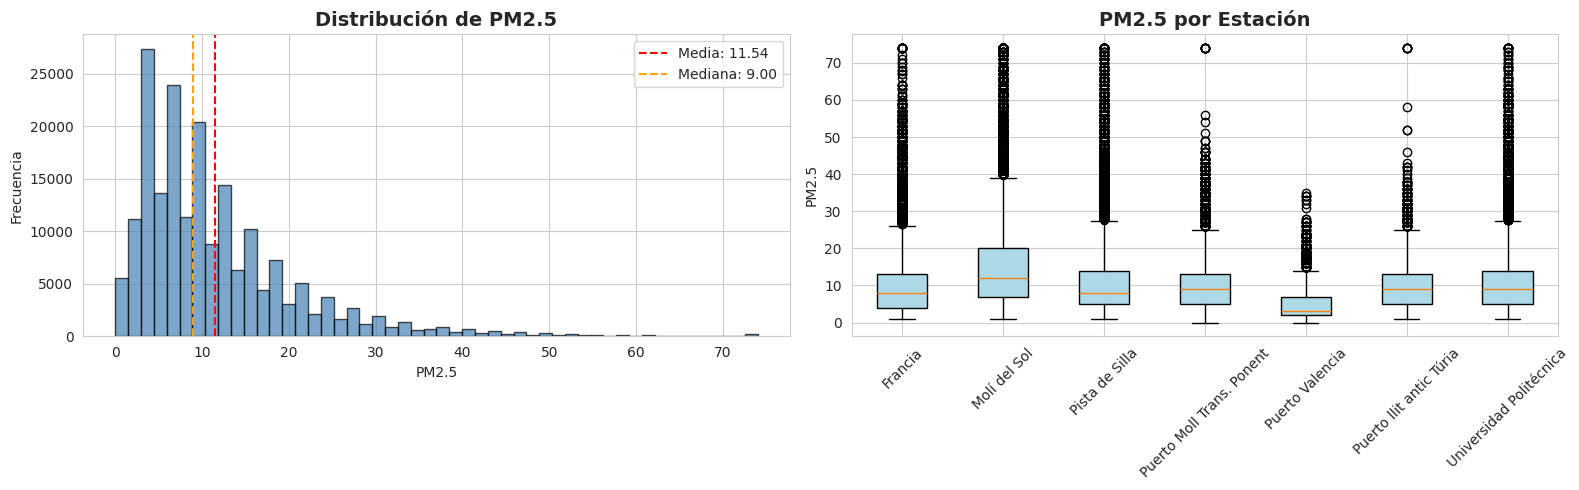

In [6]:
# 2.2 Distribución del Target (PM2.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(df['pm25'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de PM2.5', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PM2.5')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['pm25'].mean(), color='red', linestyle='--', label=f'Media: {df["pm25"].mean():.2f}')
axes[0].axvline(df['pm25'].median(), color='orange', linestyle='--', label=f'Mediana: {df["pm25"].median():.2f}')
axes[0].legend()

# Boxplot por estación
stations = df['station_name'].unique()
data_by_station = [df[df['station_name'] == s]['pm25'].values for s in stations]
bp = axes[1].boxplot(data_by_station, labels=stations, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_title('PM2.5 por Estación', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PM2.5')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


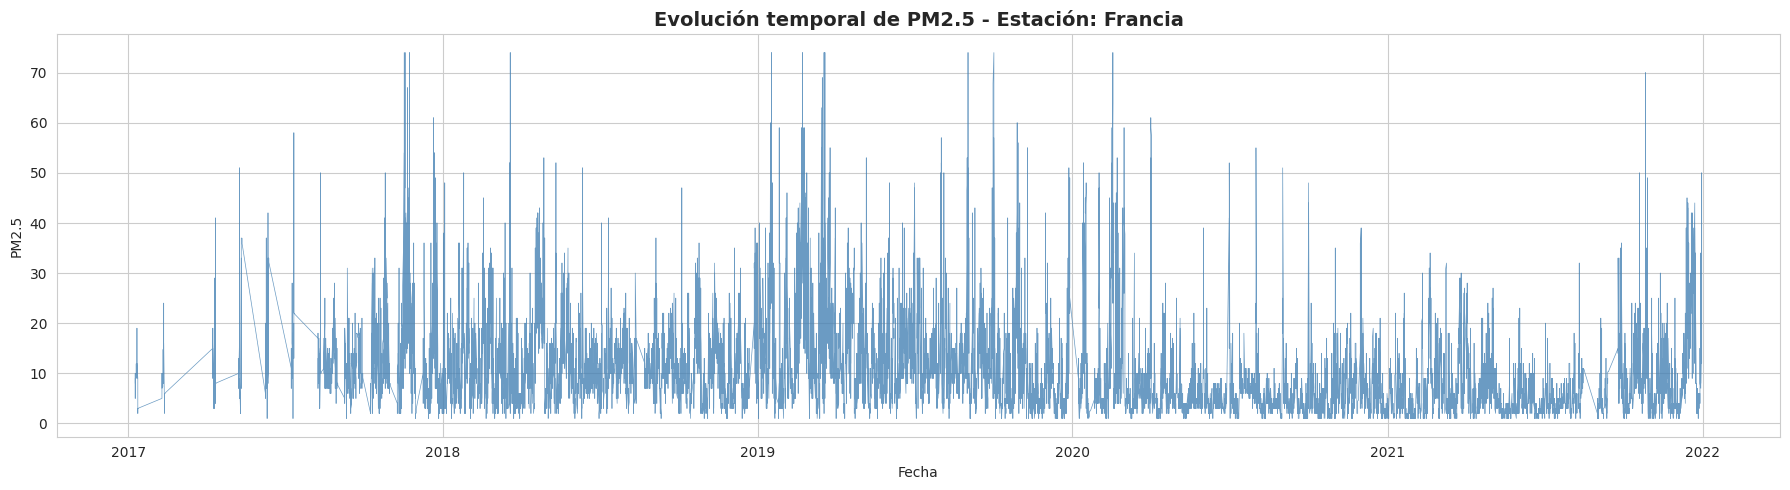

In [7]:
# 2.3 Serie temporal del PM2.5 para una estación representativa
sample_station = df['station_name'].unique()[0]
df_sample = df[df['station_name'] == sample_station]

plt.figure(figsize=(18, 5))
plt.plot(df_sample.index, df_sample['pm25'], linewidth=0.5, color='steelblue', alpha=0.8)
plt.title(f'Evolución temporal de PM2.5 - Estación: {sample_station}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()


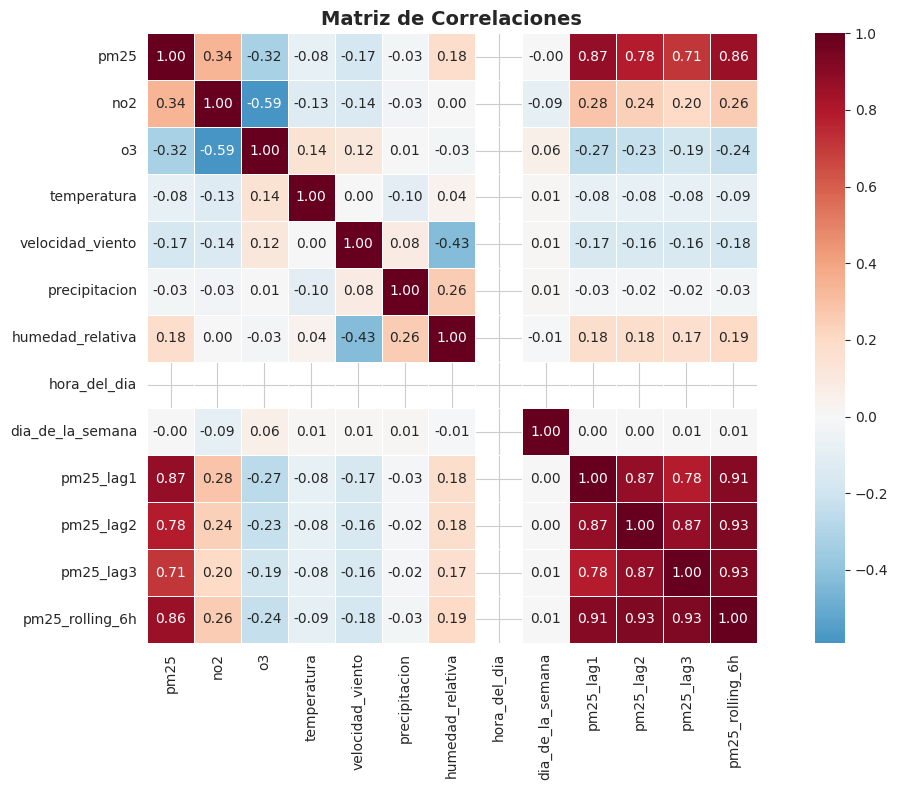

In [8]:
# 2.4 Heatmap de correlaciones entre features numéricas
# Excluimos columnas one-hot de estaciones y station_name para mayor claridad
exclude_cols = [c for c in df.columns if c.startswith('station_') or c == 'station_name']
corr_cols = [c for c in numeric_cols if c not in exclude_cols]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Matriz de Correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Feature Engineering: Transformación Seno/Coseno

Las variables temporales como `hora_del_dia` (0-23) y `dia_de_la_semana` (0-6) son **cíclicas**.
Si las usamos directamente como valores lineales, el modelo pensará que la hora 23 y la hora 0 están muy lejos,
cuando en realidad son consecutivas.

La solución es codificarlas con **seno y coseno**, mapeando los valores a un círculo unitario.
De esta forma, las horas/días consecutivos siempre estarán cerca en el espacio de features.

In [9]:
# 3.1 Transformaciones cíclicas
df['hora_sin'] = np.sin(2 * np.pi * df['hora_del_dia'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_del_dia'] / 24)
df['dia_sin'] = np.sin(2 * np.pi * df['dia_de_la_semana'] / 7)
df['dia_cos'] = np.cos(2 * np.pi * df['dia_de_la_semana'] / 7)

# Eliminar las columnas originales lineales (ya no las necesitamos)
df.drop(columns=['hora_del_dia', 'dia_de_la_semana'], inplace=True)

print("✅ Transformaciones cíclicas aplicadas")
print(f"Nuevas columnas: hora_sin, hora_cos, dia_sin, dia_cos")
print(f"Shape actual del DataFrame: {df.shape}")


✅ Transformaciones cíclicas aplicadas
Nuevas columnas: hora_sin, hora_cos, dia_sin, dia_cos
Shape actual del DataFrame: (195183, 23)


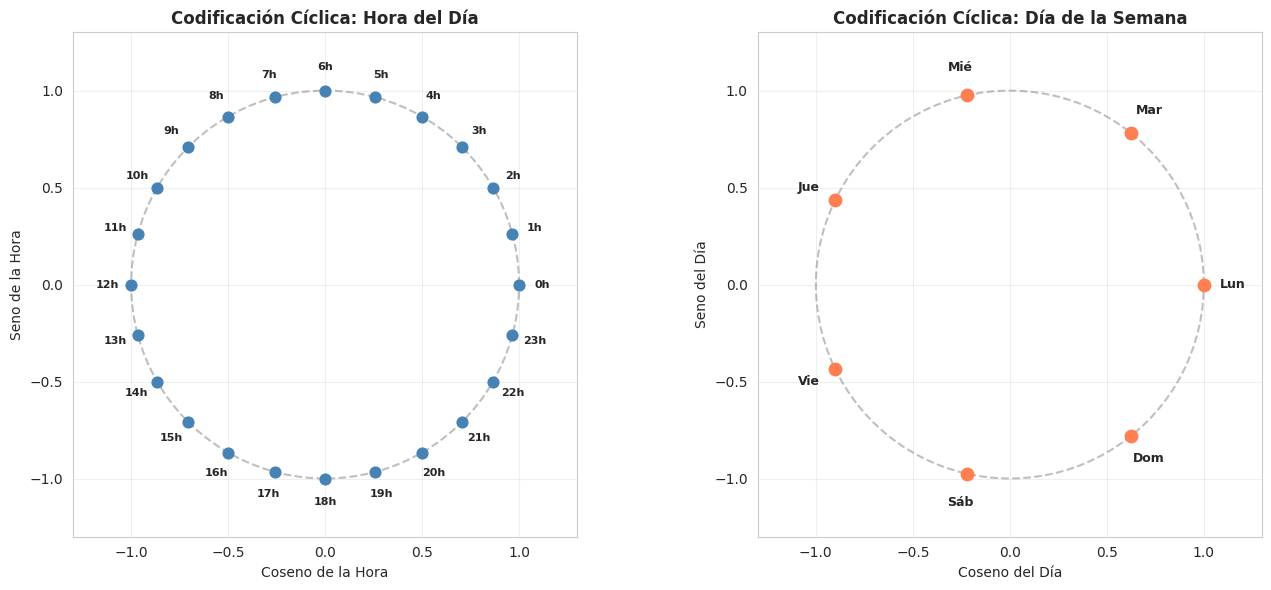

In [10]:
# 3.2 Visualización de la transformación cíclica (Círculo Unitario)
horas = np.arange(0, 24)
hora_sin = np.sin(2 * np.pi * horas / 24)
hora_cos = np.cos(2 * np.pi * horas / 24)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Círculo unitario para horas
theta = np.linspace(0, 2 * np.pi, 100)
axes[0].plot(np.cos(theta), np.sin(theta), linestyle='dashed', color='gray', alpha=0.5)
axes[0].scatter(hora_cos, hora_sin, color='steelblue', s=60, zorder=5)
for i, h in enumerate(horas):
    axes[0].annotate(f'{h}h', (hora_cos[i]*1.12, hora_sin[i]*1.12),
                     fontsize=8, ha='center', va='center', fontweight='bold')
axes[0].set_xlabel("Coseno de la Hora")
axes[0].set_ylabel("Seno de la Hora")
axes[0].set_title("Codificación Cíclica: Hora del Día", fontsize=12, fontweight='bold')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-1.3, 1.3)
axes[0].set_ylim(-1.3, 1.3)

# Círculo unitario para días
dias = np.arange(0, 7)
dia_sin = np.sin(2 * np.pi * dias / 7)
dia_cos = np.cos(2 * np.pi * dias / 7)
nombres_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

axes[1].plot(np.cos(theta), np.sin(theta), linestyle='dashed', color='gray', alpha=0.5)
axes[1].scatter(dia_cos, dia_sin, color='coral', s=80, zorder=5)
for i, d in enumerate(nombres_dias):
    axes[1].annotate(d, (dia_cos[i]*1.15, dia_sin[i]*1.15),
                     fontsize=9, ha='center', va='center', fontweight='bold')
axes[1].set_xlabel("Coseno del Día")
axes[1].set_ylabel("Seno del Día")
axes[1].set_title("Codificación Cíclica: Día de la Semana", fontsize=12, fontweight='bold')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()


## 4. Normalización de los Datos (MinMaxScaler)

Las redes neuronales LSTM funcionan mucho mejor cuando las features están en un rango similar.
Usaremos `MinMaxScaler` para escalar todas las features numéricas al rango [0, 1].

**Importante:** Guardamos el scaler para poder hacer la **transformación inversa** después y
mostrar las predicciones en valores reales de PM2.5.

In [11]:
# 4.1 Normalización con MinMaxScaler
scaler = MinMaxScaler()

# Columnas a normalizar (excluyendo station_name que es string)
cols_to_scale = [c for c in df.columns if c != 'station_name']

print(f"Columnas a normalizar ({len(cols_to_scale)}):")
for c in cols_to_scale:
    print(f"  - {c}: min={df[c].min():.4f}, max={df[c].max():.4f}")

# Aplicar normalización
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Guardar el índice de la columna pm25 para la transformación inversa
pm25_col_idx = cols_to_scale.index('pm25')

print(f"\n✅ Normalización aplicada. Índice de pm25 en el scaler: {pm25_col_idx}")
print(f"Rango de PM2.5 después de normalizar: [{df['pm25'].min():.4f}, {df['pm25'].max():.4f}]")


Columnas a normalizar (22):
  - pm25: min=0.0000, max=74.0000
  - no2: min=1.0000, max=116.0000
  - o3: min=1.0000, max=129.0000
  - temperatura: min=5.6000, max=32.2000
  - velocidad_viento: min=0.0000, max=7.5000
  - precipitacion: min=0.0000, max=127.8000
  - humedad_relativa: min=14.0000, max=91.0000
  - pm25_lag1: min=0.0000, max=74.0000
  - pm25_lag2: min=0.0000, max=74.0000
  - pm25_lag3: min=0.0000, max=74.0000
  - pm25_rolling_6h: min=0.0000, max=74.0000
  - station_Francia: min=0.0000, max=1.0000
  - station_Molí del Sol: min=0.0000, max=1.0000
  - station_Pista de Silla: min=0.0000, max=1.0000
  - station_Puerto Moll Trans. Ponent: min=0.0000, max=1.0000
  - station_Puerto Valencia: min=0.0000, max=1.0000
  - station_Puerto llit antic Túria: min=0.0000, max=1.0000
  - station_Universidad Politécnica: min=0.0000, max=1.0000
  - hora_sin: min=0.0000, max=0.0000
  - hora_cos: min=1.0000, max=1.0000
  - dia_sin: min=-0.9749, max=0.9749
  - dia_cos: min=-0.9010, max=1.0000

✅ Nor

## 5. Creación de Ventanas Temporales por Estación
Para entrenar el LSTM, transformamos el DataFrame en tensores 3D `(muestras, pasos_de_tiempo, caracteristicas)`.
Usaremos 24 horas (lags temporales) para predecir la hora siguiente (Target: pm25).
Agruparemos los datos por estación para evitar secuencias donde la última hora de la estación A se use para predecir la primera hora de la estación B.

In [12]:
def create_sequences_by_station(data, seq_length, target_col_name='pm25', group_col='station_name'):
    xs = []
    ys = []

    # Extraer nombres de las columnas para obtener los índices después
    columns = data.columns.tolist()
    target_idx = columns.index(target_col_name)

    # Agrupamos por estación
    for station, group in data.groupby(group_col):
        # Eliminamos la columna station_name ya que no se introduce como feature numérica en la LSTM
        group_no_station = group.drop(columns=[group_col])
        group_values = group_no_station.values
        target_values = group[target_col_name].values

        for i in range(len(group_values) - seq_length):
            x = group_values[i:(i + seq_length), :]
            y = target_values[i + seq_length]
            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

SEQ_LENGTH = 24 # 24 horas de historia

X, y = create_sequences_by_station(df, SEQ_LENGTH, target_col_name='pm25', group_col='station_name')
print(f'Shape de X (Input): {X.shape}')
print(f'Shape de y (Target): {y.shape}')


Shape de X (Input): (195015, 24, 22)
Shape de y (Target): (195015,)


### División en Train, Validation y Test
Dividimos aleatoriamente las secuencias generadas. Como tenemos muchas secuencias independientes
(generadas por estación), hacer shuffle está bien para generalizar el modelo.

In [13]:
# Dividimos aleatoriamente las secuencias generadas
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {X_train.shape}, {y_train.shape}')
print(f'Validation: {X_val.shape}, {y_val.shape}')
print(f'Test: {X_test.shape}, {y_test.shape}')


Train: (136510, 24, 22), (136510,)
Validation: (29252, 24, 22), (29252,)
Test: (29253, 24, 22), (29253,)


## 6. Construcción de la Arquitectura LSTM

Arquitectura multicapa con 3 capas LSTM apiladas, Dropout para regularización,
y una capa Dense intermedia antes de la salida.

In [14]:
model = Sequential([
    LSTM(128, activation='relu', input_shape=(SEQ_LENGTH, X.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,681 (545.63 KB)

 Trainable params: 139,681 (545.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento del Modelo
Aprovechando la GPU de Colab, entrenamos con:
- **EarlyStopping** para detener si no mejora la val_loss
- **ReduceLROnPlateau** para reducir el learning rate cuando se estanca

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/80
534/534 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - loss: 0.0090 - mae: 0.0634 - val_loss: 0.0059 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 2/80
534/534 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0055 - mae: 0.0475 - val_loss: 0.0046 - val_mae: 0.0412 - learning_rate: 0.0010
Epoch 3/80
534/534 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0048 - mae: 0.0430 - val_loss: 0.0042 - val_mae: 0.0394 - learning_rate: 0.0010
Epoch 4/80
534/534 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0046 - mae: 0.0413 - val_loss: 0.0043 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 5/80
534/534 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0045 - mae: 0.0401 - val_loss: 0.0042 - val_mae: 0.0399 - learning_rate: 0.0010
Epoch 6/80
533/534 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044 - mae: 0.0393
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
534/534 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0043 - mae: 0.0393 - val_loss: 0.0045 - val_mae: 0.0411 - learning_rate: 

## 8. Evaluación y Gráficos

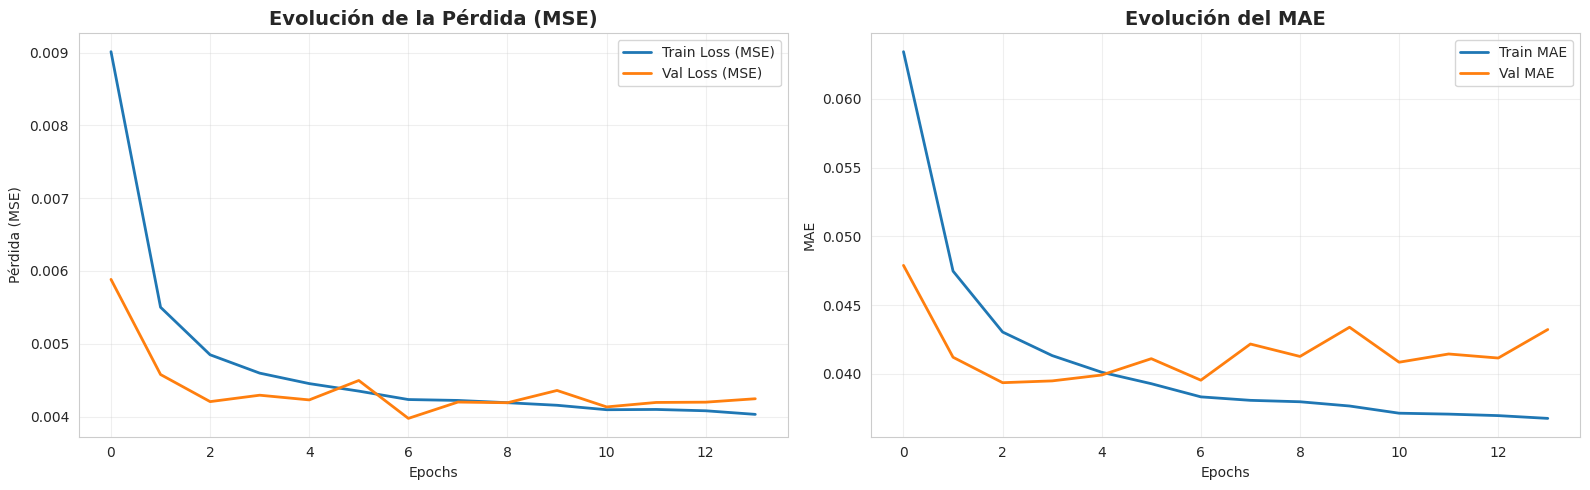

In [16]:
# 8.1 Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['loss'], label='Train Loss (MSE)', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)', linewidth=2)
axes[0].set_title('Evolución de la Pérdida (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_title('Evolución del MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
# 8.2 Predicciones sobre Test
y_pred_scaled = model.predict(X_test)

# Métricas en escala normalizada
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f'=== Métricas en escala NORMALIZADA ===')
print(f'Test MSE: {mse_scaled:.6f}')
print(f'Test MAE: {mae_scaled:.6f}')
print(f'Test R²:  {r2_scaled:.4f}')


915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
=== Métricas en escala NORMALIZADA ===
Test MSE: 0.004238
Test MAE: 0.040375
Test R²:  0.7549


In [18]:
# 8.3 Desnormalización: Convertir predicciones a valores reales de PM2.5

def inverse_transform_pm25(values_scaled, scaler, pm25_idx, total_features):
    """Desnormaliza valores de PM2.5 usando el scaler original."""
    # Crear un array dummy con la misma cantidad de features
    dummy = np.zeros((len(values_scaled), total_features))
    dummy[:, pm25_idx] = values_scaled.flatten()
    # Hacer inverse_transform
    dummy_inv = scaler.inverse_transform(dummy)
    return dummy_inv[:, pm25_idx]

total_features = len(cols_to_scale)

y_test_real = inverse_transform_pm25(y_test, scaler, pm25_col_idx, total_features)
y_pred_real = inverse_transform_pm25(y_pred_scaled, scaler, pm25_col_idx, total_features)

# Métricas en escala real
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)
r2_real = r2_score(y_test_real, y_pred_real)

print(f'=== Métricas en escala REAL (µg/m³) ===')
print(f'Test MSE:  {mse_real:.4f}')
print(f'Test RMSE: {rmse_real:.4f}')
print(f'Test MAE:  {mae_real:.4f}')
print(f'Test R²:   {r2_real:.4f}')


=== Métricas en escala REAL (µg/m³) ===
Test MSE:  23.2081
Test RMSE: 4.8175
Test MAE:  2.9878
Test R²:   0.7549


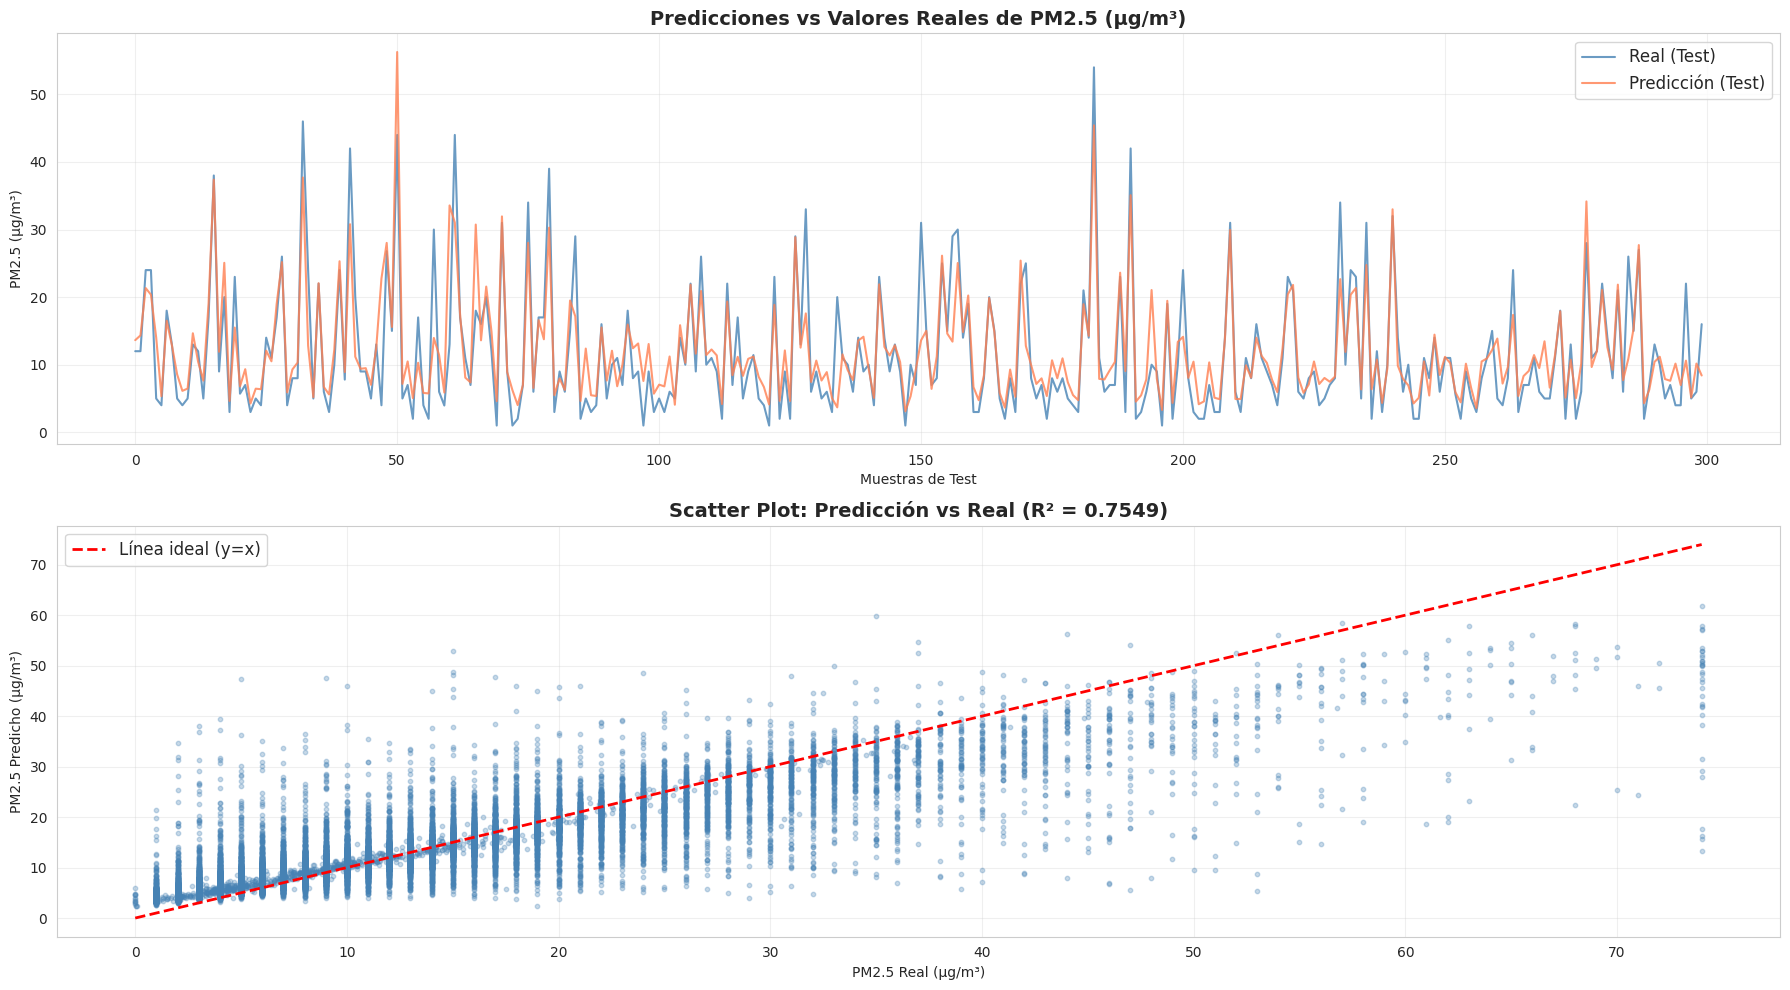

In [19]:
# 8.4 Gráficos de predicción vs realidad (valores reales)
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Predicciones vs Reales - primeras 300 muestras
n_show = 300
axes[0].plot(y_test_real[:n_show], label='Real (Test)', alpha=0.8, linewidth=1.5, color='steelblue')
axes[0].plot(y_pred_real[:n_show], label='Predicción (Test)', alpha=0.8, linewidth=1.5, color='coral')
axes[0].set_title('Predicciones vs Valores Reales de PM2.5 (µg/m³)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Muestras de Test')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Scatter Plot: Predicción vs Real
axes[1].scatter(y_test_real, y_pred_real, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Línea ideal (y=x)')
axes[1].set_title(f'Scatter Plot: Predicción vs Real (R² = {r2_real:.4f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PM2.5 Real (µg/m³)')
axes[1].set_ylabel('PM2.5 Predicho (µg/m³)')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Exportación del Modelo

In [20]:
model.save(MODEL_PATH)
print(f'✅ Modelo LSTM guardado en: {MODEL_PATH}')

# Resumen final
print(f'\n📊 Resumen del entrenamiento:')
print(f'   - Arquitectura: 3 capas LSTM (128→64→32) + Dense(16) + Dense(1)')
print(f'   - Ventana temporal: {SEQ_LENGTH} horas')
print(f'   - Features por timestep: {X.shape[2]}')
print(f'   - Total secuencias: {X.shape[0]}')
print(f'   - Train/Val/Test split: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}')
print(f'   - RMSE final (escala real): {rmse_real:.4f} µg/m³')
print(f'   - R² final: {r2_real:.4f}')


✅ Modelo LSTM guardado en: lstm_pm25_colab.keras

📊 Resumen del entrenamiento:
   - Arquitectura: 3 capas LSTM (128→64→32) + Dense(16) + Dense(1)
   - Ventana temporal: 24 horas
   - Features por timestep: 22
   - Total secuencias: 195015
   - Train/Val/Test split: 136510/29252/29253
   - RMSE final (escala real): 4.8175 µg/m³
   - R² final: 0.7549
